## 1. Jupyter Notebook — рабочая среда

Notebook состоит из **ячеек** двух типов:
- **Markdown** — текст, заголовки, формулы (эта ячейка — пример)
- **Code** — исполняемый код

Важная особенность: ячейки можно выполнять **не по порядку**! Это удобно для экспериментов, но частый источник ошибок у новичков — переменная может "остаться" от старого запуска.

Полезные горячие клавиши:
- `Shift + Enter` — выполнить ячейку и перейти к следующей
- `Esc`, затем `A` / `B` — вставить ячейку выше / ниже
- `Esc`, затем `D D` — удалить ячейку
- `Esc`, затем `M` / `Y` — сделать ячейку markdown / code


In [3]:
# Ваша первая ячейка кода
print("Привет, ML!")

# Попробуйте изменить текст и выполнить ячейку (Shift+Enter)
a = 10
a

Привет, ML!


10

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
# Магическая команда: графики будут отображаться прямо в ноутбуке
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt


**Мини-упражнение.** В ячейке ниже создайте переменную с вашим именем и выведите приветствие с помощью `print()`.

In [2]:
# Ваш код здесь
my_name = "..."
print(f"Привет, меня зовут {my_name}, и я изучаю ML!")


Привет, меня зовут ..., и я изучаю ML!


## 2. NumPy — работа с данными

NumPy — библиотека для быстрой работы с массивами чисел. Это "движок", на котором строится почти весь ML в Python.

### 2.1 Почему не обычные списки Python?


In [3]:
import time

n = 2_000_000

# Способ 1: обычный список Python + цикл
list_a = list(range(n))
list_b = list(range(n))

start = time.time()
list_result = [list_a[i] + list_b[i] for i in range(n)]
time_list = time.time() - start

# Способ 2: NumPy массивы + векторизация
arr_a = np.arange(n)
arr_b = np.arange(n)

start = time.time()
arr_result = arr_a + arr_b
time_numpy = time.time() - start

print(f"Список Python: {time_list:.4f} сек")
print(f"NumPy массив:  {time_numpy:.4f} сек")
print(f"NumPy быстрее в {time_list / time_numpy:.1f} раз")


Список Python: 0.0732 сек
NumPy массив:  0.0021 сек
NumPy быстрее в 35.2 раз


### 2.2 Создание массивов

In [4]:
a = np.array([1, 2, 3, 4, 5])
zeros = np.zeros((2, 3))
ones = np.ones((3, 3))
rng = np.arange(0, 10, 2)          # от 0 до 10 с шагом 2
lin = np.linspace(0, 1, 5)         # 5 точек равномерно от 0 до 1
rand = np.random.normal(0, 1, 5)   # 5 случайных чисел из нормального распределения

print("array:   ", a)
print("zeros:\n", zeros)
print("ones:\n", ones)
print("arange:  ", rng)
print("linspace:", lin)
print("normal:  ", rand)


array:    [1 2 3 4 5]
zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
arange:   [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]
normal:   [ 1.13850567 -0.65349702  1.98461426 -0.24522328  0.19175226]


### 2.3 Форма, индексация, срезы

In [5]:
matrix = np.arange(1, 13).reshape(3, 4)
print("Матрица 3x4:\n", matrix)
print("Форма (shape):", matrix.shape)
print("Размерность (ndim):", matrix.ndim)

print("\nЭлемент [1, 2]:", matrix[1, 2])
print("Вторая строка:", matrix[1, :])
print("Второй столбец:", matrix[:, 1])
print("Подматрица [0:2, 1:3]:\n", matrix[0:2, 1:3])


Матрица 3x4:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Форма (shape): (3, 4)
Размерность (ndim): 2

Элемент [1, 2]: 7
Вторая строка: [5 6 7 8]
Второй столбец: [ 2  6 10]
Подматрица [0:2, 1:3]:
 [[2 3]
 [6 7]]


In [6]:
# Булева индексация (маски) — один из самых важных приёмов в ML
data = np.array([3, -1, 7, -5, 2, 8, -2])
mask = data > 0
print("Данные:", data)
print("Маска (data > 0):", mask)
print("Только положительные:", data[mask])


Данные: [ 3 -1  7 -5  2  8 -2]
Маска (data > 0): [ True False  True False  True  True False]
Только положительные: [3 7 2 8]


### 2.4 Векторизованные операции и broadcasting

In [24]:
x = np.array([1, 2, 3, 4])
y = np.array([1, 20, 30, 40])

print("x + y  =", x + y)
print("x * y  =", x * y)
print("x == y =", x == y) 
print("x ** 2 =", x ** 2)
print("x + 100 (broadcasting) =", x + 100)   # число "растягивается" на весь массив


x + y  = [ 2 22 33 44]
x * y  = [  1  40  90 160]
x == y = [ True False False False]
x ** 2 = [ 1  4  9 16]
x + 100 (broadcasting) = [101 102 103 104]


### 2.5 Агрегации

In [8]:
sample = np.random.normal(loc=50, scale=10, size=1000)  # 1000 случайных значений

print("Среднее (mean):", sample.mean())
print("Стд. отклонение (std):", sample.std())
print("Минимум / Максимум:", sample.min(), "/", sample.max())
print("Сумма:", sample.sum())


Среднее (mean): 50.09223501394262
Стд. отклонение (std): 9.91461876194542
Минимум / Максимум: 19.47779225796433 / 82.0266823091739
Сумма: 50092.23501394262


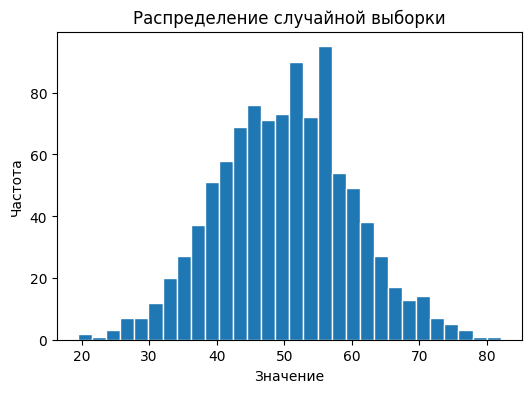

In [16]:
plt.figure(figsize=(6, 4))
plt.hist(sample, bins=30, edgecolor="white")
plt.title("Распределение случайной выборки")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()


## 3. Matplotlib — визуализация

Matplotlib — "глаза" исследователя. Без визуализации почти невозможно понять данные и результат работы модели.


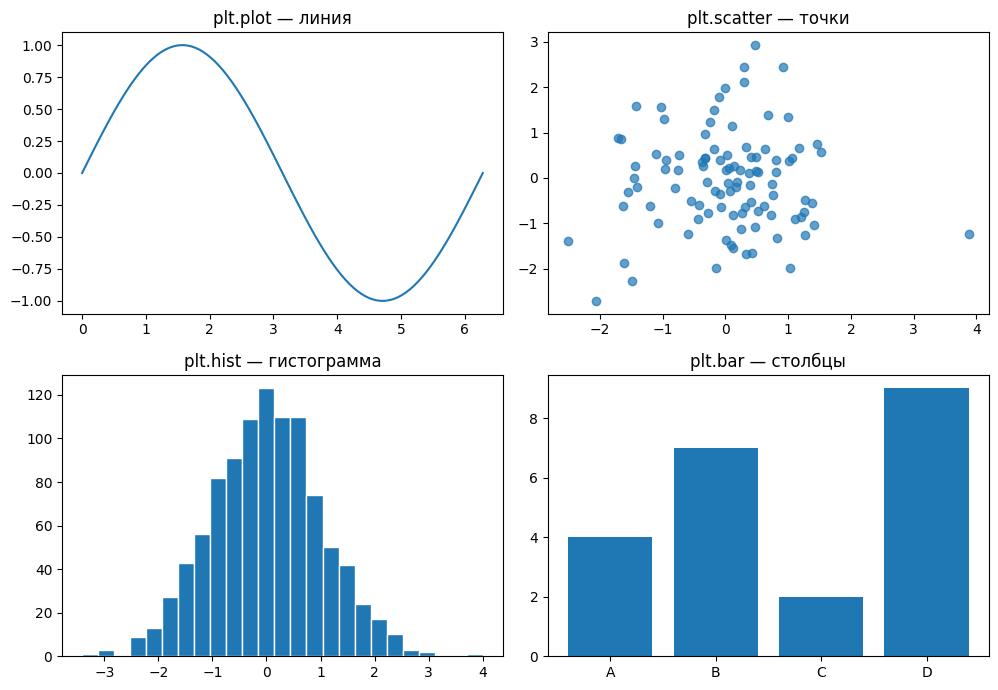

In [19]:
x = np.linspace(0, 2 * np.pi, 100)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(x, np.sin(x))
axes[0, 0].set_title("plt.plot — линия")

axes[0, 1].scatter(np.random.normal(size=100), np.random.normal(size=100))
axes[0, 1].set_title("plt.scatter — точки")

axes[1, 0].hist(np.random.normal(size=1000), bins=25, edgecolor="white")
axes[1, 0].set_title("plt.hist — гистограмма")

axes[1, 1].bar(["A", "B", "C", "D"], [4, 7, 2, 9])
axes[1, 1].set_title("plt.bar — столбцы")

plt.tight_layout()
plt.show()


Четыре базовых типа графика покрывают большинство задач визуализации в ML:
- `plot` — тренды, динамика во времени, кривые обучения
- `scatter` — облака точек, взаимосвязь двух признаков
- `hist` — распределение одного признака
- `bar` — сравнение категорий

Дальше мы используем именно `scatter` и `plot` — для датасета и для отслеживания процесса обучения.


## 4. Ищем разделяющую прямую алгоритмом восхождения на вершину

### Постановка задачи

У нас есть точки на плоскости, принадлежащие одному из двух классов. Мы хотим найти прямую

$$y = a \cdot x + b$$

которая как можно лучше разделяет эти два класса.

**Модель здесь — это всего два числа: `a` и `b`.** Обучение — это процесс подбора этих чисел так, чтобы качество разделения (accuracy) было максимальным.

Мы будем использовать **hill climbing** (восхождение на вершину):
1. Начинаем со случайных `a`, `b`
2. Делаем маленький случайный шаг
3. Если качество улучшилось — оставляем новые веса, если нет — откатываемся
4. Повторяем много раз
5. **Сохраняем каждый шаг**, чтобы потом посмотреть на "путь" весов


### 4.1 Генерируем датасет

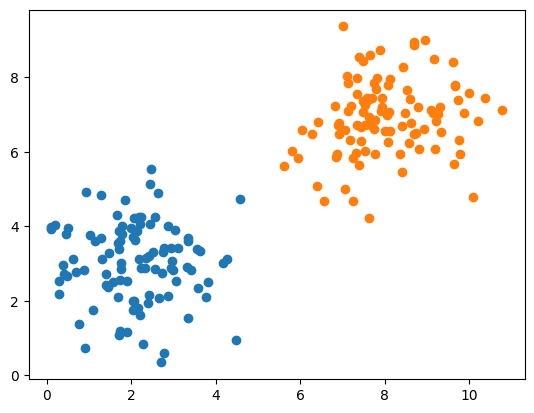

In [9]:
center1 = np.array([2, 3])
center2 = np.array([8, 7])

n_points = 100
std_dev = 1.0

group1 = np.random.normal(loc=center1, scale=std_dev, size=(n_points, 2))
group2 = np.random.normal(loc=center2, scale=std_dev, size=(n_points, 2))


plt.scatter(group1[:,0], group1[:,1])
plt.scatter(group2[:,0], group2[:,1])

#### Попытаемся угадать правильное решение

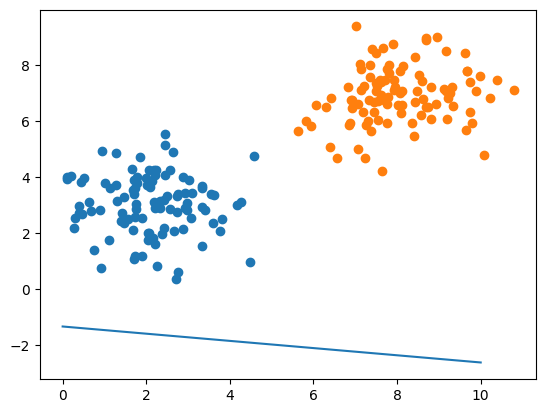

In [10]:
border = np.random.normal(size=(2))

X = np.linspace(0,10, 100)
Y = border[0]*X + border[1]

plt.plot(X,Y)
plt.scatter(group1[:,0], group1[:,1])
plt.scatter(group2[:,0], group2[:,1])

#### Сведем данные в единый объект

In [11]:
points = np.concatenate((group1, group2))
targets = np.array([1.0]*100+[0.0]*100)

### 4.2 Шаг оптимизации и потери

Прямая `y = a*x + b` делит плоскость на две области. Будем считать, что:
- если точка лежит **выше** прямой (`x2 > a*x1 + b`) → предсказываем класс 1
- если **ниже** → предсказываем класс 0


In [12]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

def train_step(points, targets, border, lr=0.1):
    output = sigmoid(border[0]*points[:,0] + border[1] - points[:,1])
    
    loss_old = (output - targets)**2
    loss_old = np.sum(loss_old)

    delta = np.random.normal(size=(2))
    new_border = border + lr*delta

    output = sigmoid(new_border[0]*points[:,0] + new_border[1] - points[:,1])

    loss_new = (output - targets)**2
    loss_new = np.sum(loss_new)

    if loss_old > loss_new:
        border = new_border

    return border

### 4.4 Алгоритм восхождения на вершину (hill climbing)

На каждой итерации:
1. Пробуем немного изменить `a` и `b` случайным шагом
2. Если новая accuracy лучше — принимаем изменение
3. Если хуже — откатываемся к предыдущим весам
4. **Сохраняем текущие `a`, `b` и accuracy в историю** — это и есть "путь" обучения


In [13]:
border = np.random.normal(size=(2))
history = []

for i in range(1000):
    border = train_step(points, targets, border, 0.1)
    history.append([border[0],border[1]])

### 4.5 Результат: разделяющая прямая после обучения

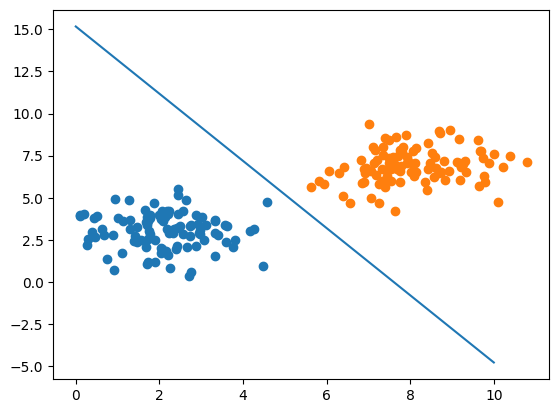

In [14]:
X = np.linspace(0,10, 100)
Y = border[0]*X + border[1]

plt.plot(X,Y)
plt.scatter(group1[:,0], group1[:,1])
plt.scatter(group2[:,0], group2[:,1])

### 4.7 Путь весов (a, b) в пространстве параметров

Мы видим, как алгоритм блуждал по пространству возможных прямых, постепенно поднимаясь к лучшему решению — отсюда и название "восхождение на вершину".


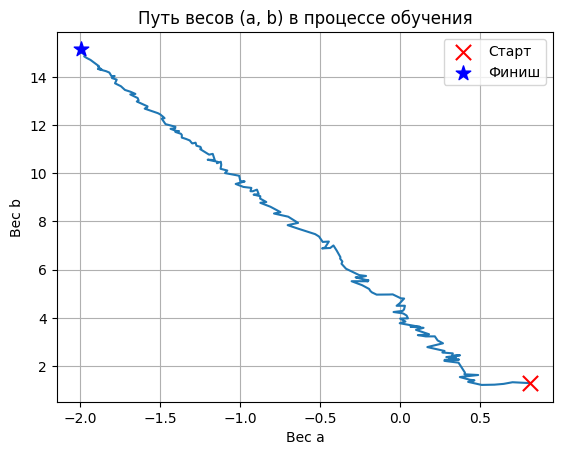

In [16]:
history = np.array(history)

plt.plot(history[:,0], history[:,1])  # соединяем путь линией
plt.scatter(history[0,0], history[0,1], color="red", s=120, marker="x", label="Старт", zorder=5)
plt.scatter(history[-1,0], history[-1,1], color="blue", s=120, marker="*", label="Финиш", zorder=5)

plt.grid()
plt.xlabel("Вес a")
plt.ylabel("Вес b")
plt.title("Путь весов (a, b) в процессе обучения")
plt.legend()


## Лабораторная работа 1
### Задача регрессии на основе алгоритма восхождения на вершину
1. Реализвать алгоритм задающий множество точек X и Y линейной функции в котором каждый элемент Y будет смещен на случайную величину
2. Задать новые случайные значения коэффициентов линейной функции и оптимизировать их под полученные данные в первом пункте при помощи алгоритма восхождения на вершину
3. Визуализировать линейную функцию с коэффициентами полученными во 2 пункте и множество точек X,Y
4. Сравнить на сколько отличаются коэффициенты линейной функции использованные для постройки начальных данных и найденные коэффициенты
5. (*) На доп балл сделайте визуализацию истории изменения весов

### Примечание
Воспользуйтесь уже готовой функцией шага оптимизации `train_step`

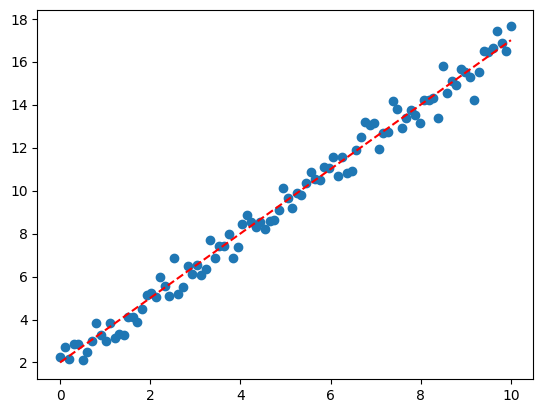

In [54]:
# пример изображения, которое должно получится после выполнения 4 пункта лабораторной
X = np.linspace(0,10, 100)
Y = 2.0 + 1.5*X - 0.5*np.random.randn(*X.shape)

# border = *random array len=2*
# for _ in range(1000):
#     border = train_step(...)

Y_true = border[0] + border[1]*X

plt.scatter(X,Y)
plt.plot(X,Y_true, '--', color='red')
